<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment_12:Neural Network and Deep Learning Basics

This assignment implemented a feedforward neural network to classify images from the Fashion MNIST dataset into 10 clothing categories.

Import all the necessary libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**Data Loading and Visualization:**

Load Fashion MNIST

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28) (60000,)
Test shape: (10000, 28, 28) (10000,)


**visualizing sample images**

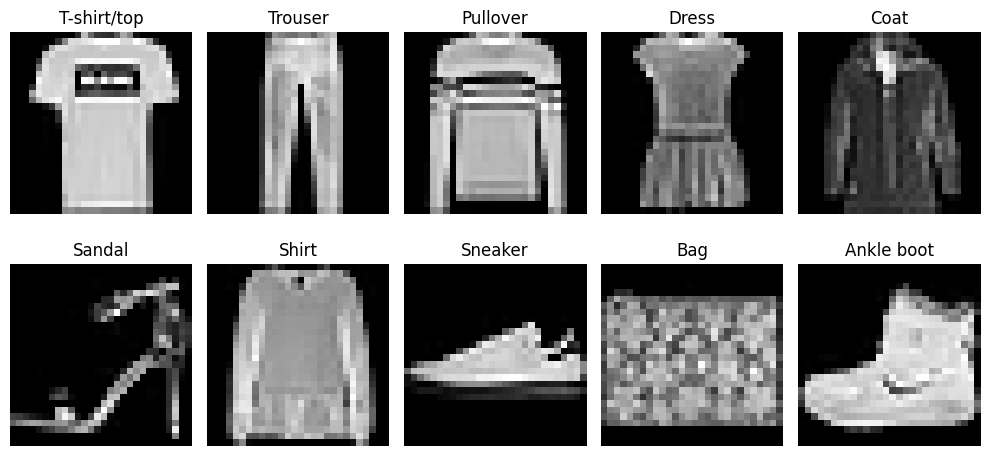

In [4]:
plt.figure(figsize=(10, 5))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


**Preprocessing.**

Normalization( Normalize pixel values to [0, 1])

In [5]:

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0



One-hot encode labels (needed for categorical_crossentropy)

In [6]:

y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)


Pixel values were normalized from the original [0,255] range to [0,1] by dividing by 255, which stabilizes and speeds up gradient-based training. labels were one-hot encoded to match the categorical cross entropy loss function.

**Data Augmentation**

 Reshape for ImageDataGenerator (needs channel dimension)

In [7]:
x_train_aug = x_train.reshape(-1, 28, 28, 1)
datagen = ImageDataGenerator(rotation_range=10,width_shift_range=0.1,
    height_shift_range=0.1,zoom_range=0.1,horizontal_flip=True)

datagen.fit(x_train_aug)

**Model**

flatten 28x28 image into 784-length vector

with 10 output classes

In [8]:
model = keras.Sequential([layers.Flatten(input_shape=(28, 28)),layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),layers.Dense(10, activation='softmax')])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

the baseline model consisting of two hidden layers (128 and 64 neurons ) with ReLU activations and a SoftMax output layers

**Training model**

In [9]:
history = model.fit(x_train, y_train_cat,batch_size=32,
    epochs=15,validation_split=0.2)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8167 - loss: 0.5127 - val_accuracy: 0.8593 - val_loss: 0.3943
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8656 - loss: 0.3718 - val_accuracy: 0.8570 - val_loss: 0.3866
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8758 - loss: 0.3365 - val_accuracy: 0.8636 - val_loss: 0.3729
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8839 - loss: 0.3142 - val_accuracy: 0.8815 - val_loss: 0.3362
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8891 - loss: 0.2986 - val_accuracy: 0.8821 - val_loss: 0.3306
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8944 - loss: 0.2823 - val_accuracy: 0.8814 - val_loss: 0.3258
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9003 - loss: 0.2693 - val_accuracy: 0.8847 - val_loss: 0.3269
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9021 - loss: 0.2607 - 


the model was trained for 10-15 epochs with a batch size of 32 , using a 20% validation split from the training set to monitor generalization performance during training.

The gap between training accuracy  and validation accuracy (88% to 89%) shows that the model performs well but does not generalize perfectly to unseen data. This indicates that further improvements such as regularization, dropout, or data augmentation could help reduce overfitting and improve generalization.

**Plotting Training Curves**

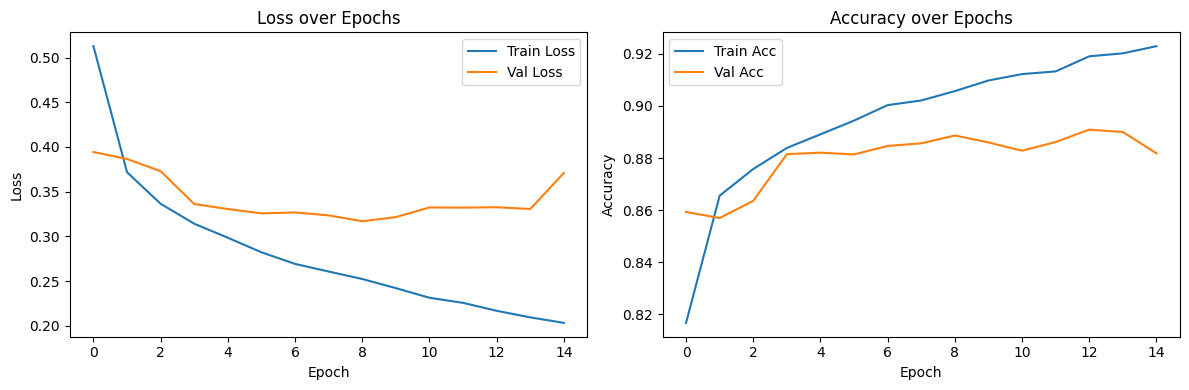

In [10]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout()
plt.show()

**Evaluate the Test set**



In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8716 - loss: 0.4006
Test Accuracy: 0.8716


In [13]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.75      0.88      0.81      1000
     Trouser       0.97      0.98      0.98      1000
    Pullover       0.71      0.87      0.78      1000
       Dress       0.94      0.77      0.85      1000
        Coat       0.82      0.76      0.79      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.73      0.63      0.67      1000
     Sneaker       0.91      0.98      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



The model performed very well on classes like Trouser, Sneaker, Bag, Sandal, and Ankle boot, with F1-scores above 0.94, indicating high precision and recall.
It performed moderately on T-shirt/top, Pullover, Coat, and Dress, with F1-scores between 0.78 and 0.85.
The weakest performance was seen in the Shirt class (F1-score = 0.67)

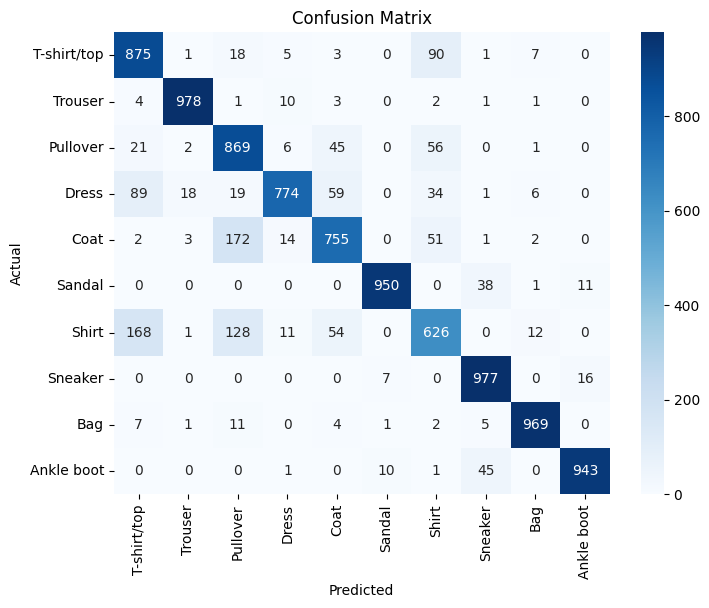

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Strong correct predictions for:**
Trouser (978 correct)
Sneaker (977 correct)
Bag (969 correct)
Sandal (950 correct)

**the errors **
T-shirt/top and Shirt (90 misclassifications)
Pullover and Coat
Dress and Coat

The model performs better on distinct objects like shoes and bags but struggles with similar clothing items.